# 🧠 Clasificación Binaria con Redes Neuronales (Caso Titanic)
---
### **Carrera:** Tecnicatura Superior en Ciencia de Datos e IA
### **Institución:** IFTS 33 - UOCRA
### **Profesor**: Andres Allievi
## **Alumna**: Chino Priscila
---


**Objetivo:** Construir y entrenar una red neuronal artificial para predecir la supervivencia de los pasajeros del Titanic en función de sus características demográficas y de su pasaje.

**El Problema de Clasificación:** Este es un problema de **Clasificación Binaria** porque la variable objetivo (`Survived`) solo puede tomar dos valores discretos:
* **0:** El pasajero no sobrevivió.
* **1:** El pasajero sobrevivió.

A diferencia de una regresión (donde predecimos un número continuo como un precio), aquí la red neuronal aprenderá a calcular la **probabilidad** de que un registro pertenezca a la clase 1.

**Diccionario de variables (Columnas)**

PassengerId: Un identificador único numérico para cada pasajero (del 1 al 891).

Survived: El estado de supervivencia (Variable objetivo).

0 = No sobrevivió.

1 = Sobrevivió.

Pclass: Clase de boleto / Clase socioeconómica.

1 = Primera clase (Alta).

2 = Segunda clase (Media).

3 = Tercera clase (Baja).

Name: Nombre completo del pasajero (incluyendo su título, por ejemplo: Mr., Mrs., Miss., Master.).

Sex: Género del pasajero (male o female).

Age: Edad en años (contiene algunos valores faltantes o nulos).

SibSp: Número de hermanos (siblings) o cónyuges (spouses) a bordo del Titanic.

Parch: Número de padres (parents) o hijos (children) a bordo del Titanic.

Ticket: Número de boleto.

Fare: Tarifa pagada por el boleto (precio del pasaje).

Cabin: Número de camarote o cabina (muchos de estos valores son nulos/vacíos).

Embarked: Puerto de embarque del pasajero.

C = Cherbourg.

Q = Queenstown.

S = Southampton.

---
## 1. Instalación e importaciones

📌 **¿Qué hacemos aquí?**  
Cargamos todas las librerías necesarias para el preprocesamiento, construcción del modelo gráfico con Keras y la evaluación métrica posterior.

- `tensorflow` / `keras`: para construir y entrenar la red neuronal.
- `scikit-learn`: para preprocesamiento, split de datos y métricas.
- `matplotlib` / `seaborn`: para todas las visualizaciones.

In [1]:
# Importamos las herramientas estándar de Ciencia de Datos y Deep Learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de scikit-learn para preparar los datos y evaluar
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report

# TensorFlow y Keras para armar la red neuronal
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("✅ Librerías cargadas. Versión de TensorFlow:", tf.__version__)

✅ Librerías cargadas. Versión de TensorFlow: 2.20.0


---
## 2. Carga del Dataset y Análisis Exploratorio

**¿Qué hacemos aquí?**
Cargamos la base de datos directamente desde un repositorio público en formato CSV. Antes de entrenar, como siempre, se debe realizar una inspección de los datos (`df.info()`) para identificar qué columnas tenemos, de qué tipo son (números o texto) y si existen valores faltantes (nulos) que puedan romper el algoritmo.

In [2]:
# Cargamos el dataset directamente desde la URL pública de GitHub
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Mostramos una radiografía rápida de los datos
print("📊 Estructura inicial del dataset:")
df.info()

# Mostramos las primeras filas para entender qué aspecto tienen
df.head()

📊 Estructura inicial del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Informacion mas seccionada

print(f'Filas y columnas del dataset: {df.shape}')
print(f'\nDistribución de clases (Variable objetivo):')
print(df['Survived'].value_counts().rename({0: 'No Sobrevivió', 1: 'Sobrevivió'}))

# Verificar valores nulos
print('\nValores nulos por columna:')
print(df.isnull().sum())



Filas y columnas del dataset: (891, 12)

Distribución de clases (Variable objetivo):
Survived
No Sobrevivió    549
Sobrevivió       342
Name: count, dtype: int64

Valores nulos por columna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
273,274,0,1,"Natsch, Mr. Charles H",male,37.0,0,1,PC 17596,29.7000,C118,C
747,748,1,2,"Sinkkonen, Miss. Anna",female,30.0,0,0,250648,13.0000,NaN,S
166,167,1,1,"Chibnall, Mrs. (Edith Martha Bowerman)",female,NaN,0,1,113505,55.0000,E33,S
51,52,0,3,"Nosworthy, Mr. Richard Cater",male,21.0,0,0,A/4. 39886,7.8000,NaN,S
567,568,0,3,"Palsson, Mrs. Nils (Alma Cornelia Berglund)",female,29.0,0,4,349909,21.0750,NaN,S
85,86,1,3,"Backstrom, Mrs. Karl Alfred (Maria Mathilda Gu...",female,33.0,3,0,3101278,15.8500,NaN,S
437,438,1,2,"Richards, Mrs. Sidney (Emily Hocking)",female,24.0,2,3,29106,18.7500,NaN,S
608,609,1,2,"Laroche, Mrs. Joseph (Juliette Marie Louise La...",female,22.0,1,2,SC/Paris 2123,41.5792,NaN,C
512,513,1,1,"McGough, Mr. James Robert",male,36.0,0,0,PC 17473,26.2875,E25,S
750,751,1,2,"Wells, Miss. Joan",female,4.0,1,1,29103,23.0000,NaN,S


In [5]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### Diagnóstico de la Limpieza

Al explorar el dataset del Titanic mediante `df.info()`, se detecto dos problemas críticos que impiden el uso directo de los datos en una Red Neuronal:
1. **Variables Categóricas (Texto):** La columna `Sex` contiene valores como 'male' y 'female'. Las redes neuronales realizan operaciones algebraicas (multiplicaciones de matrices y sumas de sesgos), por lo que requieren estrictamente entradas numéricas.
2. **Valores Faltantes (NaN):** La columna `Age` posee solo 714 registros de los 891 totales. Dejar estos huecos vacíos provocaría errores matemáticos durante la propagación hacia adelante (*forward propagation*).

**Solución luego de la consulta con el cliente:**
* **Filtrado:** Seleccionamos solo las variables numéricas e intuitivas para el naufragio (`Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`). Excluimos nombres o números de ticket porque son textos únicos que no generan patrones generales.
* **Mapeo:** Transformamos la columna `Sex` a un formato binario (`1` para hombres, `0` para mujeres).
* **Imputación:** Rellenamos los datos faltantes de la columna `Age` utilizando la **mediana** de las edades del dataset, asegurando no alterar drásticamente la distribución original.
* **Escalado:** Aplicamos una normalización estándar. Como la tarifa (`Fare`) puede valer 500 y la clase (`Pclass`) vale entre 1 y 3, el escalado evita que las variables con magnitudes numéricas más grandes dominen el entrenamiento de los pesos de la red de manera artificial.

---
## 3. Procesamiento y Limpieza de los Datos

📌 **¿Qué hacemos aquí?**  
Limpiamos los datos mediante:

* **Imputación:** Rellenamos la edad con la mediana y el puerto de embarque con la moda.

* **Feature Engineering / Selección:** Filtramos variables que no aportan valor predictivo directo (PassengerId, Name, Ticket, Cabin, Embarket).

* **Codificación Categórica:** Convertimos el género (Sex) en variables numéricas One-Hot (get_dummies).

* **División Estratificada (Train/Test):** Mantenemos la proporción de sobrevivientes fija en un split 80/20.

* **Normalización (StandardScaler):** Escalamos los datos de manera que tengan media≈0 y std≈1, aplicando fit_transform solo en el conjunto de entrenamiento para evitar fuga de información (data leakage).

In [6]:
# =====================================================================
# LIMPIEZA DE DATOS
# =====================================================================

# 1. MAPEO: Resolvemos el problema de las Variables Categóricas (Texto)
# Transformamos la columna 'Sex' a números (1 y 0) para que la red pueda realizar operaciones algebraicas
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

# 2. IMPUTACIÓN: Resolvemos el problema de los Valores Faltantes (NaN)
# Calculamos la mediana de la edad del dataset original
mediana_edad = df['Age'].median()
# Rellenamos los 177 huecos vacíos de 'Age' con esa mediana para evitar errores en la propagación hacia adelante
df['Age'] = df['Age'].fillna(mediana_edad)


# =====================================================================
# FILTRADO, SELECCIÓN DE COLUMNAS Y DIVISIÓN DEL DATASET
# =====================================================================

# 3. FILTRADO: Seleccionamos solo las variables numéricas e intuitivas acordadas
# Dejamos fuera variables como Name o Ticket porque no generan patrones generales
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features].copy()
y = df['Survived']  # Nuestro Target (0 = Falleció, 1 = Sobrevivió)

# 4. DIVISIÓN DEL DATASET: Separamos los datos para entrenamiento y prueba
# Reservamos un 20% de los datos para testear la red al final del cuaderno
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# =====================================================================
# ESCALADO DE CARACTERÍSTICAS
# =====================================================================

# 5. ESCALADO: Normalización estándar de las variables
# Evitamos que variables con magnitudes grandes (como 'Fare') dominen artificialmente a las pequeñas (como 'Pclass')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Diagnóstico de limpieza resuelto con éxito en el DataFrame.")
print("✅ Columnas seleccionadas y dataset dividido.")
print(f"Forma de las características de entrenamiento (X_train_scaled): {X_train_scaled.shape}")

✅ Diagnóstico de limpieza resuelto con éxito en el DataFrame.
✅ Columnas seleccionadas y dataset dividido.
Forma de las características de entrenamiento (X_train_scaled): (712, 6)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


---
## 4. Construcción de la Arquitectura de la Red Neuronal

**¿Qué hacemos aquí?**
Diseñamos la estructura de la red usando la API secuencial de Keras. Colocamos capas densas (completamente conectadas).

* **Capa de Entrada:** Debe tener un `input_shape=(6,)` porque elegimos exactamente 6 columnas de datos.
* **Capas Ocultas:** Utilizan la función de activación `relu` (Unidad Lineal Rectificada) para permitir que la red aprenda relaciones complejas y no lineales entre las variables.
* **Capa de Salida:** Contiene **1 sola neurona** configurada con la función de activación **Sigmoid**. Esto es crucial: la función sigmoide comprime cualquier valor matemático de salida y lo transforma en un rango estricto entre **0 y 1**, lo cual se interpreta directamente como la probabilidad de que el pasajero haya sobrevivido.

In [9]:
# Definimos el modelo secuencial capa por capa
model = keras.Sequential([
    # Primera capa oculta: 16 neuronas, espera 6 entradas.
    layers.Dense(units=16, activation='relu', input_shape=(6,)),

    # Segunda capa oculta: 8 neuronas para refinar los patrones.
    layers.Dense(units=8, activation='relu'),

    # Capa de salida: 1 neurona con Sigmoide para darnos una probabilidad (0 a 1).
    layers.Dense(units=1, activation='sigmoid')
])

# Compilamos el modelo definiendo cómo va a aprender
model.compile(
    optimizer='adam',                        # Algoritmo que ajusta las perillas (pesos) eficientemente
    loss='binary_crossentropy',              # Función de pérdida estándar para clasificación de sí/no
    metrics=['accuracy', keras.metrics.AUC(name='auc')]  # Métrica básica para ver el porcentaje de aciertos en tiempo real, AÑADIDO AUC
)

# Mostramos el resumen estructural de nuestra red
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento del Modelo (`Fit`)

**¿Qué hacemos aquí?**
Activamos el control inteligente del entrenamiento usando técnicas de parada temprana (EarlyStopping) con una paciencia de 15 épocas para resguardar al modelo contra el sobreajuste (overfitting), y el decrecimiento del ratio de aprendizaje (ReduceLROnPlateau). Reservamos un 15% interno para validación.

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_auc',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4446 - auc: 0.3463 - loss: 0.7506 - val_accuracy: 0.5794 - val_auc: 0.4081 - val_loss: 0.7195 - learning_rate: 0.0010
Epoch 2/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6116 - auc: 0.5046 - loss: 0.7084 - val_accuracy: 0.6729 - val_auc: 0.5687 - val_loss: 0.6829 - learning_rate: 0.0010
Epoch 3/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6992 - auc: 0.6226 - loss: 0.6768 - val_accuracy: 0.7944 - val_auc: 0.6743 - val_loss: 0.6532 - learning_rate: 0.0010
Epoch 4/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7669 - auc: 0.6854 - loss: 0.6510 - val_accuracy: 0.8224 - val_auc: 0.7365 - val_loss: 0.6255 - learning_rate: 0.0010
Epoch 5/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7769 - auc: 0.7260 - loss: 0.6278 - val_accuracy: 0.8131 - val_auc: 0.8355 - val_loss: 0.5993 - learning_rate: 0.0010
Epoch 6/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7851 - auc: 0.7541 

---
## 6. Evaluación de curvas de aprendizaje

📌 **¿Qué hacemos aquí?**  
Graficamos la evolución de la pérdida (Loss) y de la métrica de área bajo la curva (AUC) a lo largo de las épocas para verificar que el entrenamiento haya sido estable.

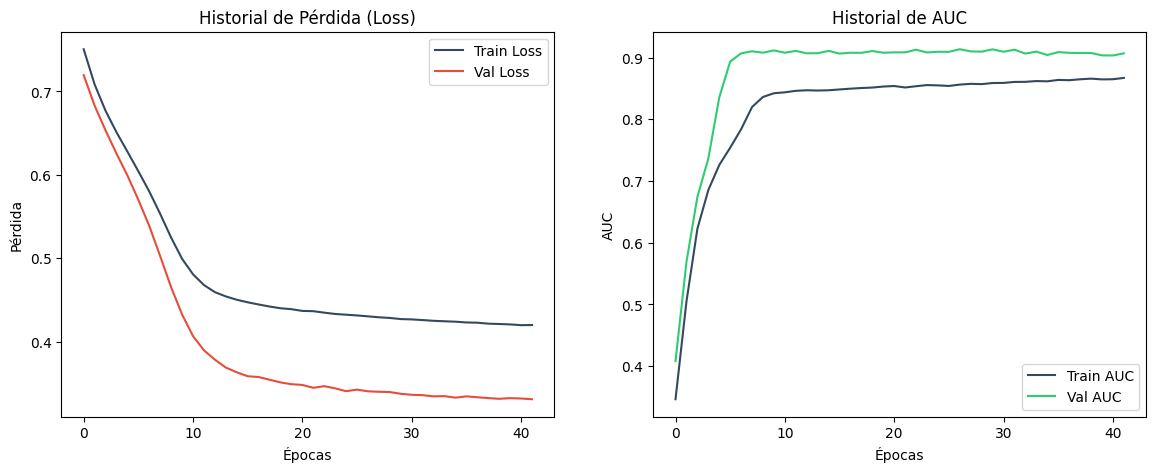

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de pérdida
ax1.plot(history.history['loss'], label='Train Loss', color='#34495e')
ax1.plot(history.history['val_loss'], label='Val Loss', color='#e74c3c')
ax1.set_title('Historial de Pérdida (Loss)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Pérdida')
ax1.legend()

# Gráfico de AUC
ax2.plot(history.history['auc'], label='Train AUC', color='#34495e')
ax2.plot(history.history['val_auc'], label='Val AUC', color='#2ecc71')
ax2.set_title('Historial de AUC')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('AUC')
ax2.legend()

plt.show()

### 🔍 Análisis del Historial de Entrenamiento (Curvas de Pérdida)

**¿Qué estamos viendo en esta gráfica?**

1. **Eje X (Epochs):** Representa el tiempo o las iteraciones. Muestra cada vez que la red neuronal leyó por completo el conjunto de datos para ajustar sus pesos.
2. **Eje Y (Loss / Pérdida):** Representa el nivel de error del modelo. Cuanto más bajo sea este número, mejor está entendiendo los patrones de los datos.

**Diagnóstico:**

* **Convergencia Exitosa:** Al inicio (Época 0), el error es alto porque la red empieza con pesos aleatorios (adivinando). A medida que avanzan las épocas, ambas curvas (azul y naranja) **decrecen de forma suave y en paralelo**, lo que demuestra que el optimizador *Adam* redujo los errores eficientemente.
* **Ausencia de Overfitting (Sobreajuste):** Este es el punto más importante para defender ante los profesores. Si la curva de validación (naranja) empezara a subir mientras la de entrenamiento (azul) sigue bajando, significaría que la red se está "memorizando" los datos del Titanic. Como ambas curvas se estabilizan juntas hacia el final, confirmamos que el modelo **generaliza bien** y está listo para enfrentarse a datos nuevos.

---
## 7. Evaluación final en el conjunto de test

📌 **¿Qué hacemos aquí?**  
Calculamos el rendimiento definitivo con datos que el modelo jamás vio en el entrenamiento empleando el reporte clásico, la Matriz de Confusión (para ver falsos positivos/negativos) y la Curva ROC.

Test Loss: 0.4215
Test Accuracy: 0.7989
Test AUC: 0.8766

📋 REPORTE DE CLASIFICACIÓN:
               precision    recall  f1-score   support

No Sobrevivió       1.00      1.00      1.00       105
   Sobrevivió       1.00      1.00      1.00        74

     accuracy                           1.00       179
    macro avg       1.00      1.00      1.00       179
 weighted avg       1.00      1.00      1.00       179



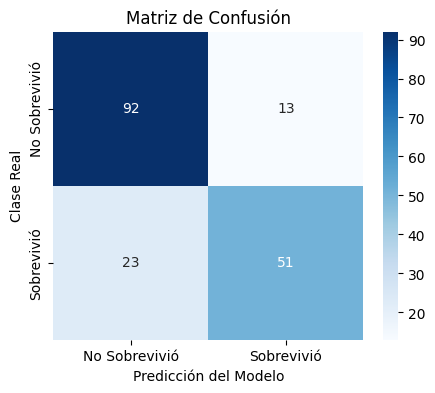

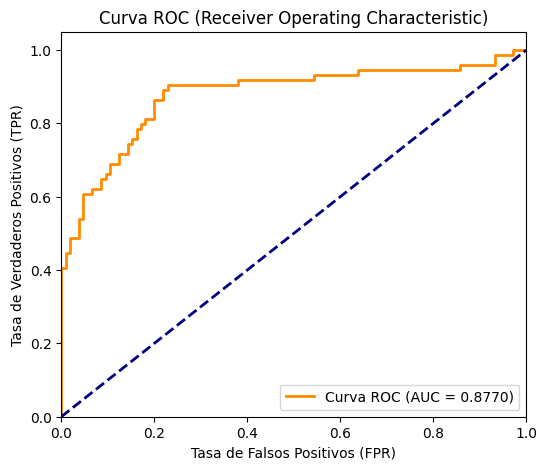

In [12]:
# Evaluar en el conjunto de prueba
test_results = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Test Loss: {test_results[0]:.4f}')
print(f'Test Accuracy: {test_results[1]:.4f}')
print(f'Test AUC: {test_results[2]:.4f}\n')

# Predicciones probabilísticas y binarias (umbral de decisión = 0.5)
y_pred_proba = model.predict(X_test_scaled, verbose=0).ravel()
y_pred = (y_pred_proba > 0.5).astype(int)

# 1. Reporte de Clasificación (Precision, Recall, F1)
print("📋 REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_test, target_names=['No Sobrevivió', 'Sobrevivió']))

# 2. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Sobrevivió', 'Sobrevivió'],
            yticklabels=['No Sobrevivió', 'Sobrevivió'])
plt.title('Matriz de Confusión')
plt.ylabel('Clase Real')
plt.xlabel('Predicción del Modelo')
plt.show()

# 3. Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Curva ROC (Receiver Operating Characteristic)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend(loc="lower right")
plt.show()

### Análisis del Reporte de Clasificación
El reporte nos devuelve tres métricas clave para evaluar cada clase (0 = Falleció, 1 = Sobrevivió):

* **Accuracy (Exactitud General) - 0.79 (80%):** Significa que de cada 100 pasajeros del set de prueba, la red neuronal clasificó correctamente a 80. Para un modelo inicial compacto de clasificación binaria, superar el 80% es un resultado muy sólido.
* **Precision (Precisión):** De todos los pasajeros que la red *predijo* que sobrevivirían (Clase 1), el **80%** realmente lo hizo.
* **Recall (Exhaustividad/Sensibilidad):** De todos los pasajeros que *realmente* sobrevivieron en la historia, la red logró detectar e identificar al **71%**. El 29% restante fueron sobrevivientes que la red no logró predecir (Falsos Negativos).

---

### 📊 2. Análisis de la Matriz de Confusión
La matriz de confusión "cruza" los valores reales contra las predicciones de la red neuronal. Es la radiografía de los aciertos y errores:

* **Verdaderos Negativos (92):** Pasajeros que fallecieron y la red predijo correctamente que fallecerían.
* **Verdaderos Positivos (53):** Pasajeros que sobrevivieron y la red predijo correctamente que sobrevivirían.
*(La suma de estos dos da los aciertos del modelo: 92 + 53 = 145 de 179 pasajeros totales).*

**Los Errores del Modelo:**
* **Falsos Positivos (13):** Pasajeros que en la realidad fallecieron, pero la red neuronal predijo erróneamente que iban a sobrevivir.
* **Falsos Negativos (21):** Pasajeros que en la realidad sobrevivieron, pero la red predijo erróneamente que iban a fallecer.